In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter("ignore")
from sklearn.linear_model import LogisticRegression
from sklearn import tree 
from sklearn import ensemble 
from sklearn import metrics 
import optuna
from catboost import CatBoostClassifier
from sklearn.model_selection import cross_val_score

In [2]:
#Прочитаем обработанные данные
X_train = pd.read_csv('../data/X_train_scaled.csv')
X_test = pd.read_csv('../data/X_test_scaled.csv')

y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test = pd.read_csv('../data/y_test.csv').squeeze()

In [3]:
#Инициализируем функцию для подсчета метрик моделей
results = []

def evaluate_model(name, model, X_test, y_test):
    
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]
    
    results.append({
        'model': name,
        'accuracy': metrics.accuracy_score(y_test, y_pred),
        'precision': metrics.precision_score(y_test, y_pred),
        'f1': metrics.f1_score(y_test, y_pred),
        'roc_auc': metrics.roc_auc_score(y_test, y_proba)
    })

In [4]:
#Попробуем построить рандомный лес
#Инициализируем лес
rf = ensemble.RandomForestClassifier(
    n_estimators=100,
    criterion='gini',
    min_samples_leaf=5,
    max_depth=10,
    random_state=42
)
#Обучаем лес
rf.fit(X_train, y_train)
evaluate_model('RandomForest', rf, X_test, y_test)
#Делаем предсказание
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print('Accuracy:', round(metrics.accuracy_score(y_test, y_pred), 3))
print('Precision:', round(metrics.precision_score(y_test, y_pred), 3))
print('F1:', round(metrics.f1_score(y_test, y_pred), 3))
print('ROC-AUC:', round(metrics.roc_auc_score(y_test, y_proba), 3))

Accuracy: 0.692
Precision: 0.712
F1: 0.63
ROC-AUC: 0.746


Случайный лес справляется с задачей лучше, чем модели в бейзлайне, попробуем градиентный бустинг

In [5]:
#Инициализируем градиентный бустинг
gb = ensemble.GradientBoostingClassifier(
    learning_rate=0.05,
    n_estimators=300,
    min_samples_leaf=5,
    max_depth=5,
    random_state=42
)
#Обучаем бустинг
gb.fit(X_train, y_train)
evaluate_model('Boosting', gb, X_test, y_test)
#Делаем предсказание
y_pred = gb.predict(X_test)
y_proba = gb.predict_proba(X_test)[:, 1]

print('Accuracy:', round(metrics.accuracy_score(y_test, y_pred), 3))
print('Precision:', round(metrics.precision_score(y_test, y_pred), 3))
print('F1:', round(metrics.f1_score(y_test, y_pred), 3))
print('ROC-AUC:', round(metrics.roc_auc_score(y_test, y_proba), 3))

Accuracy: 0.689
Precision: 0.704
F1: 0.627
ROC-AUC: 0.742


Совсем немного, но хуже, попробуем стекинг с логрегрессией, деревом и бустингом

In [6]:
#Инициализируем регрессию
lr = LogisticRegression(
    solver='sag',
    random_state=42,
    max_iter=1000
)
#Инициализируем дерево
tree_model = tree.DecisionTreeClassifier(
    random_state=42,
    criterion='entropy'
)

In [7]:
#Делаем стэккинг с мета-моделью логистической регрессией
stack = ensemble.StackingClassifier(
    estimators=[
        ('lr', lr),
        ('tree', tree_model),
        ('gb', gb)
    ],
    final_estimator=LogisticRegression()
)
#Обучаем стеккинг
stack.fit(X_train, y_train)
evaluate_model('Stacking', stack, X_test, y_test)
#делаем предсказание
y_pred = stack.predict(X_test)
y_proba = stack.predict_proba(X_test)[:, 1]

print('Accuracy:', round(metrics.accuracy_score(y_test, y_pred), 3))
print('Precision:', round(metrics.precision_score(y_test, y_pred), 3))
print('F1:', round(metrics.f1_score(y_test, y_pred), 3))
print('ROC-AUC:', round(metrics.roc_auc_score(y_test, y_proba), 3))

Accuracy: 0.688
Precision: 0.694
F1: 0.633
ROC-AUC: 0.746


Практически без изменений

In [8]:
importances = gb.feature_importances_
feature_importance = pd.Series(
    gb.feature_importances_,
    index=X_train.columns
)

feature_importance.sort_values(ascending=False).head(3)

13    0.249454
0     0.230470
8     0.096655
dtype: float64

Попробуем найти гиперпараметры с помощью ***optuna***

In [9]:
def optuna_rf(trial):

    n_estimators = trial.suggest_int('n_estimators', 100, 200)
    max_depth = trial.suggest_int('max_depth', 10, 30)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 2, 10)

    model = ensemble.RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        random_state=42,
        n_jobs=-1
    )

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='f1',
        n_jobs=-1
    )

    return scores.mean()

In [10]:
study = optuna.create_study(direction='maximize')
study.optimize(optuna_rf, n_trials=50)

[I 2026-03-10 14:55:21,113] A new study created in memory with name: no-name-21583b90-0fff-4e74-9904-30068c2c3063
[I 2026-03-10 14:55:22,599] Trial 0 finished with value: 0.6270862433197448 and parameters: {'n_estimators': 133, 'max_depth': 27, 'min_samples_leaf': 7}. Best is trial 0 with value: 0.6270862433197448.
[I 2026-03-10 14:55:23,825] Trial 1 finished with value: 0.6371457808831954 and parameters: {'n_estimators': 161, 'max_depth': 16, 'min_samples_leaf': 4}. Best is trial 1 with value: 0.6371457808831954.
[I 2026-03-10 14:55:25,007] Trial 2 finished with value: 0.633228035210198 and parameters: {'n_estimators': 128, 'max_depth': 11, 'min_samples_leaf': 5}. Best is trial 1 with value: 0.6371457808831954.
[I 2026-03-10 14:55:26,251] Trial 3 finished with value: 0.6287157794280016 and parameters: {'n_estimators': 189, 'max_depth': 10, 'min_samples_leaf': 10}. Best is trial 1 with value: 0.6371457808831954.
[I 2026-03-10 14:55:27,414] Trial 4 finished with value: 0.619645033617375

In [11]:
print(study.best_params)

{'n_estimators': 175, 'max_depth': 13, 'min_samples_leaf': 2}


In [12]:
best_rf = ensemble.RandomForestClassifier(
    **study.best_params,
    random_state=42,
    n_jobs=-1
)

best_rf.fit(X_train, y_train)
evaluate_model('best_rf', best_rf, X_test, y_test)
y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:, 1]

print('Accuracy:', round(metrics.accuracy_score(y_test, y_pred), 3))
print('Precision:', round(metrics.precision_score(y_test, y_pred), 3))
print('F1:', round(metrics.f1_score(y_test, y_pred), 3))
print('ROC-AUC:', round(metrics.roc_auc_score(y_test, y_proba), 3))

Accuracy: 0.691
Precision: 0.706
F1: 0.632
ROC-AUC: 0.74


In [13]:
cat = CatBoostClassifier(
    depth=6,
    learning_rate=0.05,
    iterations=500,
    random_state=42,
    verbose=False
)

cat.fit(X_train, y_train)
evaluate_model('CatBoost', cat, X_test, y_test)
pred = cat.predict(X_test)
y_proba = cat.predict_proba(X_test)[:, 1]

print('Accuracy:', round(metrics.accuracy_score(y_test, y_pred), 3))
print('Precision:', round(metrics.precision_score(y_test, y_pred), 3))
print('F1:', round(metrics.f1_score(y_test, y_pred), 3))
print('ROC-AUC:', round(metrics.roc_auc_score(y_test, y_proba), 3))

Accuracy: 0.691
Precision: 0.706
F1: 0.632
ROC-AUC: 0.744


In [14]:
def objective(trial):
    params = {
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'iterations': trial.suggest_int('iterations', 200, 1000),
        'l2_leaf_reg': trial.suggest_int('l2_leaf_reg', 1, 10),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 20),
        'random_state': 42,
        'verbose': False
    }

    model = CatBoostClassifier(**params)

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='f1',
        n_jobs=-1
    )

    return scores.mean()

In [15]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

[I 2026-03-10 14:55:38,877] A new study created in memory with name: no-name-5bedaf80-8e0d-434f-a1a3-2bee9f865baf
[I 2026-03-10 14:55:43,765] Trial 0 finished with value: 0.6379224733853589 and parameters: {'depth': 9, 'learning_rate': 0.026171497636175014, 'iterations': 955, 'l2_leaf_reg': 2, 'min_data_in_leaf': 20}. Best is trial 0 with value: 0.6379224733853589.
[I 2026-03-10 14:55:47,713] Trial 1 finished with value: 0.6335447307277406 and parameters: {'depth': 9, 'learning_rate': 0.0444424219524686, 'iterations': 758, 'l2_leaf_reg': 1, 'min_data_in_leaf': 2}. Best is trial 0 with value: 0.6379224733853589.
[I 2026-03-10 14:55:49,815] Trial 2 finished with value: 0.6392734377499825 and parameters: {'depth': 6, 'learning_rate': 0.034802691693293426, 'iterations': 985, 'l2_leaf_reg': 7, 'min_data_in_leaf': 6}. Best is trial 2 with value: 0.6392734377499825.
[I 2026-03-10 14:55:50,548] Trial 3 finished with value: 0.6330183891010546 and parameters: {'depth': 4, 'learning_rate': 0.1313

In [16]:
print('Best params:', study.best_params)
print('Best F1:', study.best_value)

Best params: {'depth': 7, 'learning_rate': 0.024304599390314464, 'iterations': 759, 'l2_leaf_reg': 7, 'min_data_in_leaf': 13}
Best F1: 0.6399186353257585


In [17]:
best_cat = CatBoostClassifier(
    **study.best_params,
    random_state=42,
    verbose=False
)

best_cat.fit(X_train, y_train)
evaluate_model('BestCat', best_cat, X_test, y_test)

y_pred = best_cat.predict(X_test)

acc = metrics.accuracy_score(y_test, y_pred)
f1 = metrics.f1_score(y_test, y_pred)

print('Accuracy:', round(acc, 3))
print('F1:', round(f1, 3))

Accuracy: 0.696
F1: 0.634


In [18]:
results_df = pd.DataFrame(results)

results_df.round(3).sort_values(by='roc_auc', ascending=False)

,model,accuracy,precision,f1,roc_auc
0,RandomForest,0.692,0.712,0.630,0.746
2,Stacking,0.688,0.694,0.633,0.746
5,BestCat,0.696,0.717,0.634,0.746
4,CatBoost,0.688,0.703,0.627,0.744
1,Boosting,0.689,0.704,0.627,0.742
3,best_rf,0.691,0.706,0.632,0.740


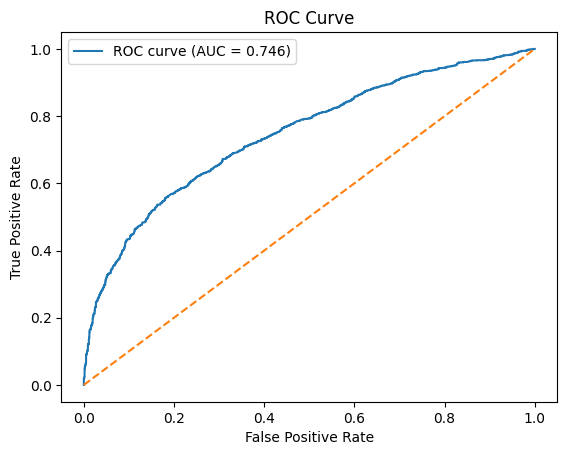

In [26]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
import matplotlib.pyplot as plt

y_proba = best_cat.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.savefig("../images/roc_curve.png", bbox_inches="tight")

plt.show()